In [2]:
import pandas as pd
import re
import jieba
# 读取 Excel
df = pd.read_excel("合并表.xlsx",sheet_name = 'comments')
content_column = df['content']
print("共读入评论：", len(content_column))
df.head()

共读入评论： 240


,comment_id,movie_id,user_name,user_avatar,comment_link,comment_time,comment_star_rating,content
0,4258483845,35883131,方枪枪,https://img9.doubanio.com/icon/u2586116-96.jpg,https://movie.douban.com/subject/35883131/comm...,2024-12-14,4,看完第一感觉是奇怪。明明挺简单的故事，却让人看了动容甚至还有些热血。后来想明白了，主创其实就...
1,4413197850,35883131,archivistzz,https://img1.doubanio.com/icon/u52847715-98.jpg,https://movie.douban.com/subject/35883131/comm...,2025-01-14,5,作品完成度和呈现太好了 好到看不到任何瑕疵也不在意任何瑕疵 永远在诟病角色长相和眼距的那群人...
2,3942593087,35883131,赵胤奇,https://img2.doubanio.com/icon/u149394663-1.jpg,https://movie.douban.com/subject/35883131/comm...,2024-12-15,5,本来觉得和第一部有点同质化只想给四星的，还是五星吧，没办法，做得太好了。\n最后一段观众都退...
3,4382187497,35883131,yuan,https://img9.doubanio.com/icon/u2711526-14.jpg,https://movie.douban.com/subject/35883131/comm...,2024-12-14,3,电影为马保国平反，都是黑心资本在陷害我们传武啊。
4,3708129981,35883131,世界在此定格,https://img3.doubanio.com/icon/u4323578-3.jpg,https://movie.douban.com/subject/35883131/comm...,2024-12-17,5,阿娟是野草中的咸鱼，无人问津，隐入尘烟，拳王是水草中的热带鱼，养尊处优，被保护得很好，但那层...


In [3]:
# 1. 缺失值处理：删除空评论
df = df.dropna(subset=["content"]).copy()

# 2. 去重：删除完全相同的评论
df = df.drop_duplicates(subset=["content"]).reset_index(drop=True)

# 3. 文本清洗：只保留中文、数字和常见标点
def clean_text(text):
    # 只留中文、数字、标点：  
    # 中日韩统一表意文字 \u4e00-\u9fff
    # 数字 0-9
    # 中文标点  \u3000-\u303F
    # 全角标点  \uFF00-\uFFEF
    cleaned = re.findall(r"[\u4e00-\u9fff0-9\u3000-\u303F\uFF00-\uFFEF]+", text)
    return "".join(cleaned)

df["cleaned"] = df["content"].astype(str).apply(clean_text)

# 再次去掉清洗后变成空串的行
df = df[df["cleaned"].str.strip() != ""].reset_index(drop=True)

In [6]:
print("共读入评论：", len(df))

共读入评论： 240


In [8]:
import stopwordsiso as stopwordsiso
# 4. 加载 stopwordsiso 的中文停用词集合
stopwords = stopwordsiso.stopwords("zh")

# 5. 分词 + 去停用词
def tokenize_and_filter(text):
    words = jieba.lcut(text)
    # 保留非停用词，且去掉长度为1的无意义符号
    return " ".join([w for w in words if w not in stopwords and len(w) > 1])

df["filtered"] = df["cleaned"].apply(tokenize_and_filter)

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\12269\AppData\Local\Temp\jieba.cache
Loading model cost 0.679 seconds.
Prefix dict has been built successfully.


In [10]:
from transformers import pipeline

# 6. 初始化情感分类 pipeline
# Use a pipeline as a high-level helper

from transformers import pipeline

# 确保model和tokenizer指向同一个本地目录
model_path = r"C:\Users\12269\代码\CnOpenData豆瓣网电影评论数据\CnOpenData电影评分数据（试用）\bert-finetuned-semantic-chinese"

classifier = pipeline(
    "text-classification",
    model=model_path,
    tokenizer=model_path  # 使用相同路径
)

Device set to use cpu


In [12]:
# 7. 批量分类（分批避免 OOM）
labels, scores = [], []
batch_size = 8
texts = df["cleaned"].tolist()
for i in range(0, len(texts), batch_size):
    batch = texts[i : i + batch_size]
    results = classifier(batch, batch_size=len(batch))
    labels.extend([r["label"] for r in results])
    scores.extend([r["score"] for r in results])

# 8. 将结果写回
df["star_label"]   = labels
df["confidence"]   = scores

# 9. 映射到二分类
def to_binary(label):
    star = int(label.split("_")[1])
    return "负面" if star <= 3 else "正面"

df["binary_label"] = df["star_label"].map(to_binary)

# 10. 查看前几行
print(df[["filtered", "star_label", "binary_label", "confidence"]].head())

                                            filtered star_label binary_label  \
0  第一 感觉 奇怪 明明 简单 故事 动容 热血 后来 明白 主创 其实 认真 简单 故事 明...     Star_3           负面   
1  作品 完成度 呈现 太好了 看不到 瑕疵 不在意 瑕疵 永远 诟病 角色 长相 眼距 那群人...     Star_5           正面   
2  本来 觉得 第一部 有点 同质化 只想 四星 五星 办法 太好了 最后 一段 观众 退场 两...     Star_5           正面   
3                               电影 保国 平反 黑心 资本 陷害 传武     Star_3           负面   
4  阿娟 野草 咸鱼 无人问津 隐入 尘烟 拳王 水草 热带鱼 养尊处优 保护 那层 防护罩 打...     Star_3           负面   

   confidence  
0    0.707835  
1    0.923275  
2    0.965401  
3    0.750129  
4    0.765088  


In [13]:
output_path = "comments_with_sentiment.xlsx"
df.to_excel(output_path, index=False)
print("已保存：", output_path)


已保存： comments_with_sentiment.xlsx


# 方法一：TF-IDF

In [19]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

In [23]:
# 2. 文本与标签
X = df["content"].astype(str).tolist()
y = df["binary_label"].map({"正面": 1, "负面": 0}).tolist()


In [25]:
# 3. 划分训练/测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [27]:
# 4. 文本向量化：TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,    # 最多保留 5000 个重要特征词
    ngram_range=(1,2),    # 同时考虑 1-gram 和 2-gram
    stop_words=None
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)


In [29]:
# 5. 定义并训练 MLPClassifier（多层感知机）
mlp = MLPClassifier(
    hidden_layer_sizes=(100, 50),  # 两层隐藏层，分别 100 和 50 个神经元
    activation="relu",             # 隐藏层激活函数用 ReLU
    solver="adam",                 # 优化算法用 Adam
    alpha=1e-4,                    # L2 正则化系数，防止过拟合
    batch_size=32,                 # 每次梯度更新用 32 个样本
    learning_rate_init=1e-3,       # 初始学习率
    max_iter=200,                   # 最多迭代 200 个 epoch
    random_state=42
)
mlp.fit(X_train_tfidf, y_train)


MLPClassifier(batch_size=32, hidden_layer_sizes=(100, 50), random_state=42)

In [31]:
# 6. 在测试集上评估
y_pred = mlp.predict(X_test_tfidf)
acc = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=["负面", "正面"], digits=4)

print(f"测试集准确率: {acc:.4f}\n")
print("分类报告:\n", report)


测试集准确率: 0.4375

分类报告:
               precision    recall  f1-score   support

          负面     0.4545    0.8696    0.5970        23
          正面     0.2500    0.0400    0.0690        25

    accuracy                         0.4375        48
   macro avg     0.3523    0.4548    0.3330        48
weighted avg     0.3480    0.4375    0.3220        48



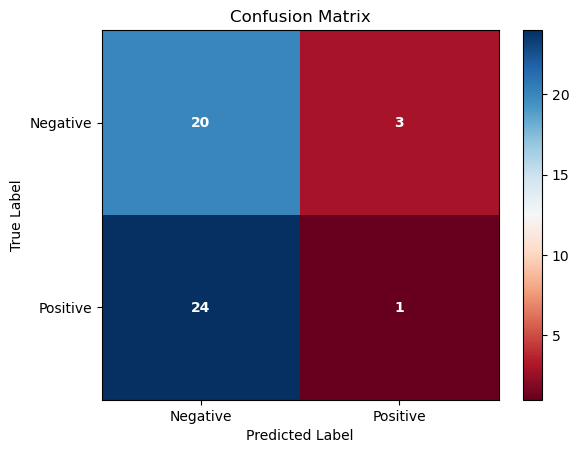

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
 
# 假定已有
# y_test, y_pred, class_names = ["负面","正面"]
class_names = ["Negative", "Positive"]

# 1. 混淆矩阵
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm, interpolation='nearest', aspect='auto', cmap=plt.cm.RdBu)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0,1], class_names)
plt.yticks([0,1], class_names)

# 白色加粗字体
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center', color='white', fontweight='bold')

plt.colorbar()
plt.savefig("confusion_matrix.png")  # 保存为文件
plt.show()

In [35]:
# 8. 显示部分测试预测结果
results_df = pd.DataFrame({
    "评论": X_test[:10],
    "真实标签": ["正面" if label==1 else "负面" for label in y_test[:10]],
    "预测标签": ["正面" if pred==1 else "负面" for pred in y_pred[:10]]
})
results_df

,评论,真实标签,预测标签
0,阿木这个角色其实就是提醒者，他不做选择，但他的旁观视角和最后的旁白，是这场时间旅途的见证,正面,负面
1,太争气了太争气了太争气了太争气了太争气了太争气了太争气了太争气了太争气了太争气了,负面,负面
2,土味画风、混乱剧情、强行穿越………到底谁爱看啊？,负面,负面
3,这次国漫没有神话IP，并且是挑战几乎没玩过的新题材，拍出来的成品却一点也不稚嫩，还巧妙融入了...,正面,负面
4,原来的导演呢？这个建模无法原谅,负面,负面
5,没有雄狮，也不见了少年，只剩拙劣的狗血与鸡血；舍弃了舞狮和广东元素，前作所有的长处便全部化为...,负面,负面
6,其实比哪吒2好，可惜未能爆,正面,负面
7,如坐针毡,负面,负面
8,刚看了可能是最后排片的《雄狮少年2》，看到一半我就明白为什么被骂了，还骂的那么没水准的一致。...,负面,正面
9,整个设定都挺《闪点悖论》的，很多细节也有种闪电侠的感觉。但是，抛除这个设定，片子也基本不剩什...,负面,负面


# 方法二：词向量word2vec

In [45]:
from gensim.models import KeyedVectors

w2v_path = r"C:\Users\12269\代码\CnOpenData豆瓣网电影评论数据\CnOpenData电影评分数据（试用）\douban-movie-1000w-Word2Vec.200.15.bin"

w2v_model = KeyedVectors.load_word2vec_format(w2v_path, binary=True, unicode_errors='ignore')
print("词向量加载完成，词表大小：", len(w2v_model))

词向量加载完成，词表大小： 426646


In [47]:
import pandas as pd
import numpy as np
import jieba
from gensim.models import KeyedVectors
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

In [49]:
texts = df["content"].astype(str).tolist()
labels = df["binary_label"].map({"正面": 1, "负面": 0}).tolist()

# 分词
#tokenized = [list(jieba.cut(text)) for text in texts]

In [51]:
import stopwordsiso as stopwordsiso

# 获取中文停用词集合
stopwords = stopwordsiso.stopwords("zh")

# 查看前 10 个
list(stopwords)[:100]


['既然',
 '犹且',
 '结果',
 '即便',
 '第',
 '任',
 '人们',
 '某某',
 '那边',
 '归齐',
 '哪怕',
 '地',
 '或曰',
 '光是',
 '不只',
 '乃至于',
 '如果',
 '能',
 '诸位',
 '临',
 '俺们',
 '每当',
 '着',
 '自各儿',
 '向着',
 '彼时',
 '所',
 '沿着',
 '从而',
 '如是',
 '但',
 '借',
 '不至于',
 '以至',
 '否则',
 '余外',
 '因',
 '宁可',
 '让',
 '吗',
 '二来',
 '各个',
 '６',
 '加以',
 '哪些',
 '要是',
 '有的',
 '喔唷',
 '可见',
 '再其次',
 '吧哒',
 '就要',
 '因了',
 '本地',
 '另外',
 '这会儿',
 '遵循',
 '由此',
 '罢了',
 '这时',
 '不光',
 '的话',
 '即如',
 '即若',
 '咦',
 '之所以',
 '才',
 '此地',
 '与其说',
 '连同',
 '再说',
 '既是',
 '其它',
 '不但',
 '不尽然',
 '凭借',
 '年',
 '要不',
 '什',
 '随后',
 '＆',
 '分',
 '８',
 '别的',
 '不得',
 '如上',
 '两者',
 '可',
 '便于',
 '咧',
 '此处',
 '倘',
 '她们',
 '在于',
 '如同',
 '乃至',
 '若非',
 '眨眼',
 '起',
 '其他']

In [53]:
# 分词
tokenized = []
for text in texts:
    words = jieba.cut(text)
    filtered = [w for w in words if w not in stopwords and w.strip()]
    tokenized.append(filtered)

In [55]:
import numpy as np

def sentence_vector(words, model, dim):
    vecs = [model[w] for w in words if w in model]
    if not vecs:
        return np.zeros(dim, dtype=float)
    return np.mean(vecs, axis=0)

# 维度
dim = w2v_model.vector_size

# 构建特征矩阵
X = np.vstack([sentence_vector(words, w2v_model, dim) for words in tokenized])
y = np.array(labels)

print("特征矩阵维度：", X.shape)


特征矩阵维度： (240, 200)


In [57]:
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, accuracy_score

# 划分
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 定义并训练 MLP
mlp = MLPClassifier(
    hidden_layer_sizes=(200,100,50),
    activation="relu",
    solver="adam",
    alpha=1e-4,
    batch_size=64,
    learning_rate_init=1e-3,
    max_iter=200,
    early_stopping=True,        # 启用早停
    n_iter_no_change=10,        # 连续 10 轮 loss 没下降就停止
    random_state=42
)
mlp.fit(X_train, y_train)

# 评估
y_pred = mlp.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=["负面","正面"]))


Accuracy: 0.6666666666666666
              precision    recall  f1-score   support

          负面       0.67      0.61      0.64        23
          正面       0.67      0.72      0.69        25

    accuracy                           0.67        48
   macro avg       0.67      0.66      0.66        48
weighted avg       0.67      0.67      0.67        48



In [59]:
import matplotlib.pyplot as plt
# 3. 输出 loss 曲线
print("训练损失曲线 (loss_curve_):")
print(mlp.loss_curve_)

训练损失曲线 (loss_curve_):
[0.7049621171857111, 0.6376131158632142, 0.5891529507791561, 0.543985105851942, 0.4966708867341242, 0.4514980292600871, 0.4055093198364146, 0.3570780282422836, 0.311444348273124, 0.26962936086196776, 0.23559839857016351, 0.19476825294255282, 0.16699645899003687, 0.13766841528811974, 0.11079106258463003, 0.09172913307253594, 0.07551564125054622, 0.05719914957858921, 0.04731862884354887, 0.03808713402852702, 0.029793869634028164, 0.023245399553734256, 0.0189412003319931, 0.015130047567621601]


In [61]:
# 4. 如果使用早停，还能看到每轮验证准确率
if hasattr(mlp, "validation_scores_"):
    print("验证集准确率曲线 (validation_scores_):")
    print(mlp.validation_scores_)

验证集准确率曲线 (validation_scores_):
[0.55, 0.55, 0.6, 0.65, 0.7, 0.7, 0.7, 0.7, 0.8, 0.8, 0.75, 0.8, 0.85, 0.85, 0.8, 0.85, 0.8, 0.85, 0.85, 0.85, 0.85, 0.85, 0.85, 0.8]


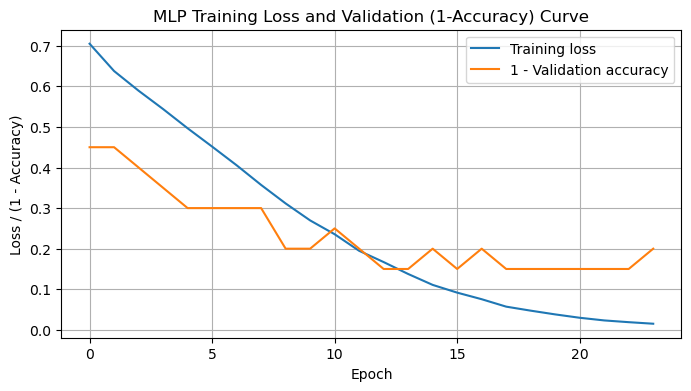

In [63]:
# 5. 绘制曲线
plt.figure(figsize=(8,4))
plt.plot(mlp.loss_curve_, label="Training loss")
if hasattr(mlp, "validation_scores_"):
    # 将验证 accuracy 转成 validation loss 风格（1-acc）也可直接画 acc
    plt.plot([1 - s for s in mlp.validation_scores_], label="1 - Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Loss / (1 - Accuracy)")
plt.title("MLP Training Loss and Validation (1-Accuracy) Curve")
plt.legend()
plt.grid(True)
plt.show()

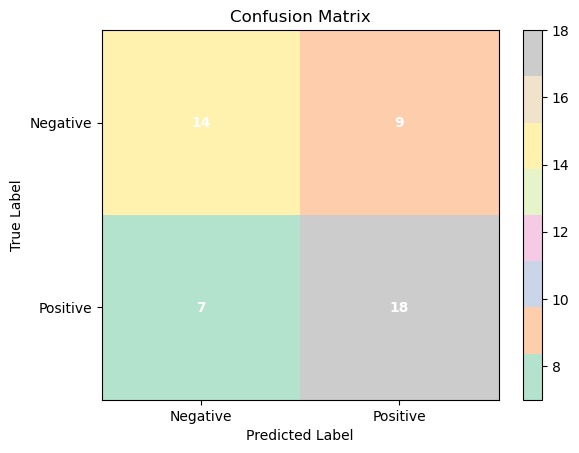

In [65]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, precision_recall_fscore_support
 
# 假定已有
# y_test, y_pred, class_names = ["负面","正面"]
class_names = ["Negative", "Positive"]

# 1. 混淆矩阵
cm = confusion_matrix(y_test, y_pred)

plt.figure()
plt.imshow(cm, interpolation='nearest', aspect='auto', cmap=plt.cm.Pastel2)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks([0,1], class_names)
plt.yticks([0,1], class_names)

# 白色加粗字体
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, str(cm[i,j]), ha='center', va='center', color='white', fontweight='bold')

plt.colorbar()
plt.savefig("confusion_matrix.png")  # 保存为文件
plt.show()


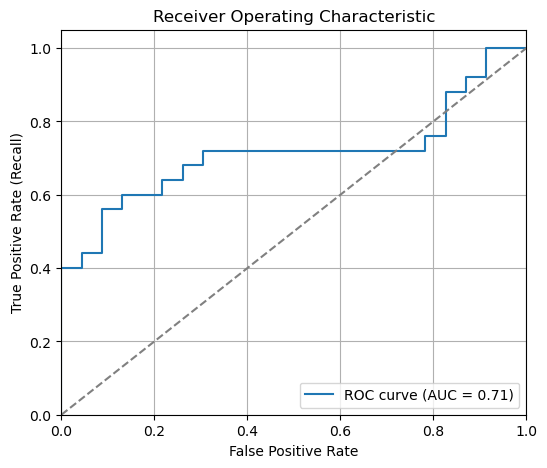

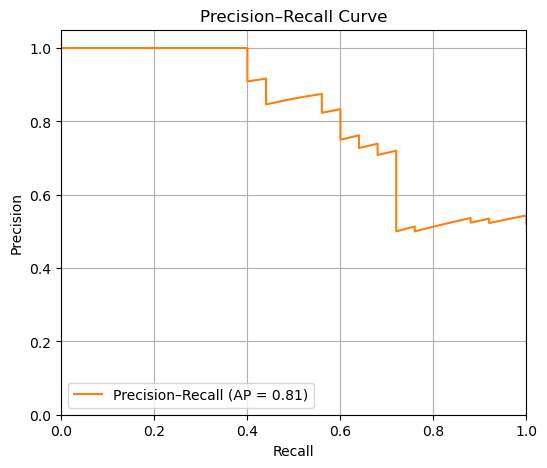

In [67]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score
)

# 1. 获取测试集上的预测分数（取正类概率）
y_score = mlp.predict_proba(X_test)[:, 1]  # 假设 label=1 是“正面”

# 2. ROC 曲线 & AUC
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc = roc_auc_score(y_test, y_score)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='C0',
         label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# 3. Precision–Recall 曲线 & Average Precision
precision, recall, _ = precision_recall_curve(y_test, y_score)
avg_prec = average_precision_score(y_test, y_score)

plt.figure(figsize=(6,5))
plt.plot(recall, precision, color='C1',
         label=f'Precision–Recall (AP = {avg_prec:.2f})')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve')
plt.legend(loc='lower left')
plt.grid(True)
plt.show()


In [69]:
 mlp.predict_proba(X_test)

array([[8.9189488e-01, 1.0810513e-01],
       [3.8864332e-01, 6.1135668e-01],
       [9.7881871e-01, 2.1181272e-02],
       [1.9542038e-01, 8.0457962e-01],
       [9.9662125e-01, 3.3787761e-03],
       [9.4212276e-01, 5.7877228e-02],
       [3.4534752e-02, 9.6546525e-01],
       [9.9961931e-01, 3.8072292e-04],
       [2.2936606e-01, 7.7063394e-01],
       [6.9272137e-01, 3.0727860e-01],
       [5.8005226e-01, 4.1994774e-01],
       [5.9014791e-01, 4.0985209e-01],
       [8.8859880e-01, 1.1140119e-01],
       [2.9837513e-01, 7.0162487e-01],
       [2.6691699e-01, 7.3308301e-01],
       [9.8513472e-01, 1.4865304e-02],
       [7.8130221e-01, 2.1869777e-01],
       [5.7432485e-01, 4.2567515e-01],
       [1.5863431e-01, 8.4136569e-01],
       [1.9056201e-03, 9.9809438e-01],
       [4.4860935e-01, 5.5139065e-01],
       [3.1303465e-02, 9.6869653e-01],
       [3.6150843e-01, 6.3849157e-01],
       [2.5681317e-02, 9.7431868e-01],
       [3.0387032e-01, 6.9612968e-01],
       [8.2609212e-01, 1.

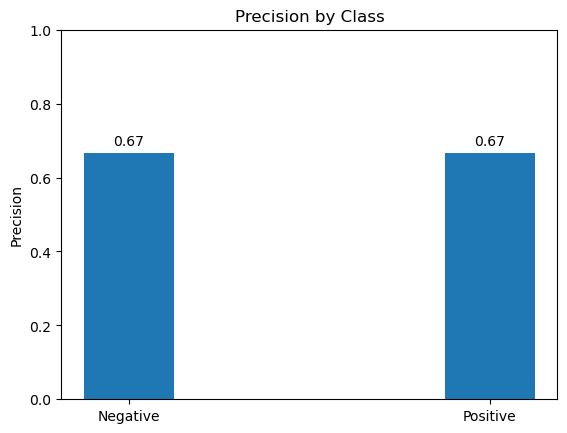

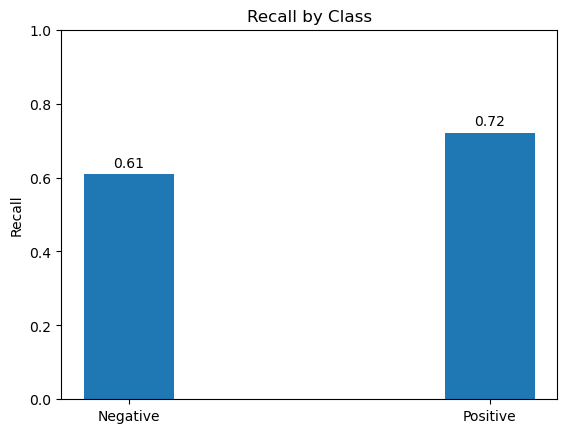

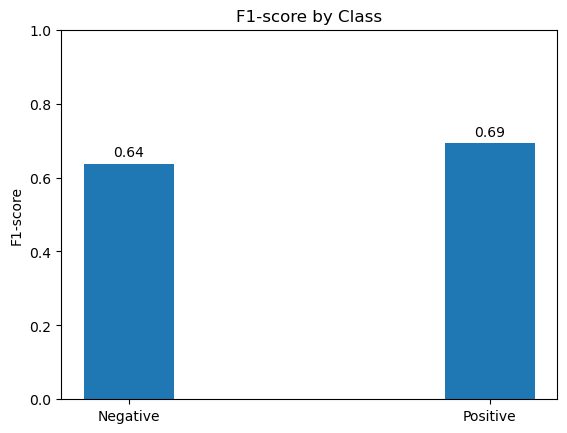

In [71]:
# 2. Precision / Recall / F1 条形图
import numpy as np

# 计算三项指标
precisions, recalls, f1s, supports = precision_recall_fscore_support(
    y_test, y_pred, labels=[0,1], zero_division=0
)
metrics = np.vstack([precisions, recalls, f1s])  # shape (3,2)
labels = ["Precision","Recall","F1-score"]

# 画图
x = np.arange(len(class_names))  # 类别位置
width = 0.25

for idx, metric_name in enumerate(labels):
    plt.figure()
    plt.bar(x, metrics[idx], width)
    plt.xticks(x, class_names)
    plt.ylabel(metric_name)
    plt.title(f"{metric_name} by Class")
    plt.ylim(0, 1)
    for i, v in enumerate(metrics[idx]):
        plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
    plt.show()


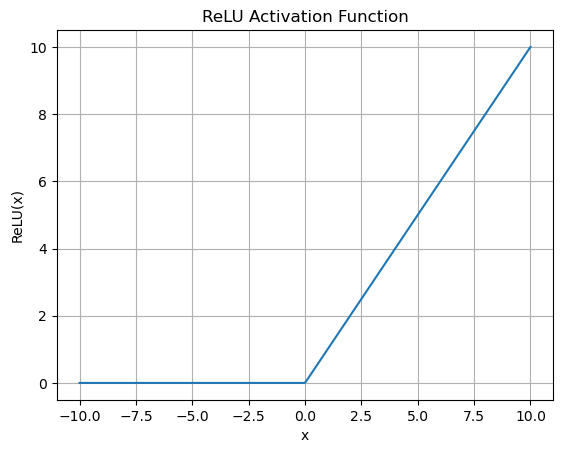

In [73]:
import numpy as np
import matplotlib.pyplot as plt

# Generate x values
x = np.linspace(-10, 10, 400)
# Compute ReLU
y = np.maximum(0, x)

# Plotting
plt.figure()
plt.plot(x, y)
plt.title("ReLU Activation Function")
plt.xlabel("x")
plt.ylabel("ReLU(x)")
plt.grid(True)
plt.show()
